# Analyse par régime de crue (par trajectoire)

Objectif : comparer des modèles (checkpoints) **par trajectoire** et agréger ensuite **par régime** (ex: bins de `Q_peak` extrait du nom du PKL : `Group_X_peak_YYYY_...pkl`).

Sorties :
- un CSV long `per_event_metrics.csv` contenant, pour chaque `exp / epoch / event / horizon` : `MSE(h,u,v)`, `CSI`, et diagnostics wetness (fractions, FP/FN, biais).
- des agrégations par régime (`peak bins`) et des plots.

Notes :
- Le calcul est coûteux : commence avec peu de `DYNAMIC_DIR`, peu d'epochs, et `OVERLAP=1` (échantillonnage grossier) puis densifie.
- On calcule `CSI_all` sur **tous** les nœuds (comme `eval_checkpoints_minimal` / `one_page`) et `CSI_int` sur l'intérieur (BC exclues) pour diagnostic.


In [1]:
import os, sys, re, math
from pathlib import Path

import torch, dgl  # noqa: F401
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ajouter le repo au PYTHONPATH
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from python.create_dgl_dataset import TelemacDataset
from python.CustomMeshGraphNet import MeshGraphNet
from modulus.launch.utils import load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:


DATA_DIR = "/work/m24046/m24046mrcr/paper/Experience2/Multimesh_8_32.bin"

DYNAMIC_DIR = [ 
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_2600_Group_1_peak_2600_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_2_peak_1000_Group_2_peak_1000_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_2_peak_1200_Group_2_peak_1200_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_2_peak_1600_Group_2_peak_1600_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_4_peak_2000_Group_4_peak_2000_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_1200_Group_1_peak_1200_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_2400_Group_1_peak_2400_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_3_peak_3400_Group_3_peak_3400_0_0-80_interpolated.pkl",
]

EXPERIMENTS = {
     "E2_Baseline": {"ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience2/Seed0/", "epochs": [600, 700, 800, 850, 900]},
     "E4_pushforward": {"ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience4_1/Seed0/", "epochs": [600, 700, 800, 850, 900]},
     "E6_1_pushforward_tversky_07_03": {"ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience6_1/Seed0/", "epochs": [600, 700, 800, 850, 900,1000]},
     "E6_2_pushforward_tversky_05_05": {"ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience6_2/Seed0/", "epochs": [600, 700, 800, 850]},
}

NUM_INPUT_FEATURES = 9
NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0

# Horizons (pas de 30 min)
HORIZONS_STEPS = [6, 12, 24]
THRESHOLD_M = 0.05

OVERLAP = 1
MASK_BOUNDARY = True

# Limite pour debug (None = toutes les fenêtres du dataset)
MAX_SEQUENCES_PER_EVENT = None

# Cache
CACHE_CSV = "per_event_metrics.csv"
FORCE_RECOMPUTE = True

# Régimes par bins de Q_peak (extrait du nom)
PEAK_BINS = [0, 1800, 2600, float("inf")]
PEAK_LABELS = ["<1800","1800-2600",">=2600"]


In [3]:
# =====================
# Parsing des trajectoires (Group / peak)
# =====================

_RE = re.compile(r"Group_(?P<group>\d+)_peak_(?P<peak>\d+)")

def parse_event_info(path: str):
    base = os.path.basename(path)
    m = _RE.search(base)
    if m is None:
        return {
            "event": base,
            "group": None,
            "peak": None,
        }
    return {
        "event": base,
        "group": int(m.group("group")),
        "peak": int(m.group("peak")),
    }

events_df = pd.DataFrame([parse_event_info(p) | {"path": p} for p in DYNAMIC_DIR])
events_df

,event,group,peak,path
0,Group_1_peak_2600_Group_1_peak_2600_0_0-80_int...,1,2600,/work/m24046/m24046mrcr/results_data_30min_35_...
1,Group_2_peak_1000_Group_2_peak_1000_0_0-80_int...,2,1000,/work/m24046/m24046mrcr/results_data_30min_35_...
2,Group_2_peak_1200_Group_2_peak_1200_0_0-80_int...,2,1200,/work/m24046/m24046mrcr/results_data_30min_35_...
3,Group_2_peak_1600_Group_2_peak_1600_0_0-80_int...,2,1600,/work/m24046/m24046mrcr/results_data_30min_35_...
4,Group_4_peak_2000_Group_4_peak_2000_0_0-80_int...,4,2000,/work/m24046/m24046mrcr/results_data_30min_35_...
5,Group_1_peak_1200_Group_1_peak_1200_0_0-80_int...,1,1200,/work/m24046/m24046mrcr/results_data_30min_35_...
6,Group_1_peak_2400_Group_1_peak_2400_0_0-80_int...,1,2400,/work/m24046/m24046mrcr/results_data_30min_35_...
7,Group_3_peak_3400_Group_3_peak_3400_0_0-80_int...,3,3400,/work/m24046/m24046mrcr/results_data_30min_35_...


In [5]:
# =====================
# Modèle / dataset helpers
# =====================

def build_model():
    return MeshGraphNet(
        NUM_INPUT_FEATURES,
        NUM_EDGE_FEATURES,
        NUM_OUTPUT_FEATURES,
        processor_size=MP_LAYERS,
        hidden_dim_processor=64,
        hidden_dim_node_encoder=64,
        hidden_dim_edge_encoder=64,
        hidden_dim_node_decoder=64,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )

def load_model_checkpoint(model, ckpt_dir, epoch):
    load_checkpoint(ckpt_dir, models=model, device=device, epoch=epoch)
    model.to(device)
    model.eval()
    return model

def build_dataset_for_event(dynamic_file, ckpt_dir, sequence_length, overlap, split="test"):
    return TelemacDataset(
        name=f"eval_{split}",
        data_dir=DATA_DIR,
        dynamic_data_files=[dynamic_file],
        split=split,
        ckpt_path=ckpt_dir,
        normalize=True,
        sequence_length=sequence_length,
        overlap=overlap,
    )

def _denorm(xn, mean, std):
    return xn * std + mean

def _renorm(x, mean, std):
    return (x - mean) / (std + 1e-12)


In [5]:
# =====================
# Évaluation : métriques par event
# =====================

def evaluate_model_per_event(
    model,
    ds,
    horizons_steps,
    threshold=0.05,
    mask_boundary=True,
    max_sequences=None,
):
    stats = ds.node_stats
    dyn_start = ds.base_graph.ndata["static"].shape[1]

    mx = torch.tensor([stats["h"].item(), stats["u"].item(), stats["v"].item()], device=device)
    sx = torch.tensor([stats["h_std"].item(), stats["u_std"].item(), stats["v_std"].item()], device=device)
    dy_mean = torch.tensor([stats["delta_h"].item(), stats["delta_u"].item(), stats["delta_v"].item()], device=device)
    dy_std = torch.tensor([
        stats["delta_h_std"].item(),
        stats["delta_u_std"].item(),
        stats["delta_v_std"].item(),
    ], device=device)

    agg = {
        h: {
            # MSE sur tous les nœuds (BC incluses)
            "count_all": 0,
            "sqerr_sum_all": np.zeros(3, dtype=np.float64),
            "tp_all": 0,
            "fp_all": 0,
            "fn_all": 0,
            # Wetness diagnostics sur intérieur (BC exclues)
            "count_int": 0,
            "bias_sum_int": 0.0,
            "wet_pred_sum_int": 0,
            "wet_gt_sum_int": 0,
            "tp_int": 0,
            "fp_int": 0,
            "fn_int": 0,
        }
        for h in horizons_steps
    }

    nseq = len(ds) if max_sequences is None else min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        g = graphs[0].to(device)
        static_part = g.ndata["x"][:, :dyn_start]
        xn_t = g.ndata["x"][:, dyn_start : dyn_start + 3]

        onehot = static_part[:, :4]
        q_mask = (onehot == torch.tensor([0, 0, 1, 0], device=device)).all(dim=1)
        h_mask = (onehot == torch.tensor([0, 1, 0, 0], device=device)).all(dim=1)
        interior_mask = ~(q_mask | h_mask) if mask_boundary else torch.ones_like(q_mask)

        for t in range(max_h):
            with torch.no_grad():
                y_pred_n = model(g.ndata["x"], g.edata["x"], g)

            x_t = _denorm(xn_t, mx, sx)
            y_pred = _denorm(y_pred_n, dy_mean, dy_std)
            x_t1 = x_t + y_pred

            x_gt_n = graphs[t + 1].ndata["x"][:, dyn_start : dyn_start + 3].to(device)
            x_gt = _denorm(x_gt_n, mx, sx)

            # BC injection
            x_t1[q_mask] = x_gt[q_mask]
            x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]

            step = t + 1
            if step in horizons_steps:
                a = agg[step]

                # --- MSE all nodes ---
                diff_all = x_t1 - x_gt
                n_all = int(diff_all.shape[0])
                a["count_all"] += n_all
                a["sqerr_sum_all"] += (diff_all**2).sum(dim=0).detach().cpu().numpy()

                # --- CSI all nodes ---
                h_pred_all = x_t1[:, 0].detach().cpu().numpy()
                h_gt_all = x_gt[:, 0].detach().cpu().numpy()
                pred_wet_all = h_pred_all >= threshold
                gt_wet_all = h_gt_all >= threshold
                a["tp_all"] += int(np.logical_and(pred_wet_all, gt_wet_all).sum())
                a["fp_all"] += int(np.logical_and(pred_wet_all, ~gt_wet_all).sum())
                a["fn_all"] += int(np.logical_and(~pred_wet_all, gt_wet_all).sum())

                # --- Wetness diagnostics interior ---
                h_pred = x_t1[:, 0][interior_mask]
                h_gt = x_gt[:, 0][interior_mask]
                if h_pred.numel() > 0:
                    hp = h_pred.detach().cpu().numpy()
                    hg = h_gt.detach().cpu().numpy()
                    pred_wet = hp >= threshold
                    gt_wet = hg >= threshold
                    n = int(hp.size)
                    a["count_int"] += n
                    a["bias_sum_int"] += float((hp - hg).sum())
                    a["wet_pred_sum_int"] += int(pred_wet.sum())
                    a["wet_gt_sum_int"] += int(gt_wet.sum())
                    a["tp_int"] += int(np.logical_and(pred_wet, gt_wet).sum())
                    a["fp_int"] += int(np.logical_and(pred_wet, ~gt_wet).sum())
                    a["fn_int"] += int(np.logical_and(~pred_wet, gt_wet).sum())

            # reinjection
            xn_t = _renorm(x_t1, mx, sx)
            g = g.clone()
            g.ndata["x"] = torch.cat([static_part, xn_t], dim=1)

    summary = {}
    for h in horizons_steps:
        a = agg[h]

        # MSE (all)
        if a["count_all"] > 0:
            mse = (a["sqerr_sum_all"] / a["count_all"]).tolist()
        else:
            mse = [math.nan, math.nan, math.nan]

        # CSI (all)
        denom_all = a["tp_all"] + a["fp_all"] + a["fn_all"]
        csi_all = (a["tp_all"] / denom_all) if denom_all > 0 else math.nan

        # Wetness diagnostics (interior)
        if a["count_int"] > 0:
            wet_pred = a["wet_pred_sum_int"] / a["count_int"]
            wet_gt = a["wet_gt_sum_int"] / a["count_int"]
            denom_int = a["tp_int"] + a["fp_int"] + a["fn_int"]
            csi_int = (a["tp_int"] / denom_int) if denom_int > 0 else math.nan
            bias_mean = a["bias_sum_int"] / a["count_int"]
            fp_rate = a["fp_int"] / a["count_int"]
            fn_rate = a["fn_int"] / a["count_int"]
        else:
            wet_pred = math.nan
            wet_gt = math.nan
            csi_int = math.nan
            bias_mean = math.nan
            fp_rate = math.nan
            fn_rate = math.nan

        summary[h] = {
            "mse_h": float(mse[0]),
            "mse_u": float(mse[1]),
            "mse_v": float(mse[2]),
            "mse_mean": float(np.nanmean(mse)),
            "csi_all": float(csi_all),
            "csi_int": float(csi_int),
            "bias_mean": float(bias_mean),
            "wet_frac_pred": float(wet_pred),
            "wet_frac_gt": float(wet_gt),
            "wet_frac_delta": float(wet_pred - wet_gt) if (wet_pred == wet_pred and wet_gt == wet_gt) else math.nan,
            "false_pos_rate": float(fp_rate),
            "false_neg_rate": float(fn_rate),
        }
    return summary


def build_event_datasets(dynamic_files, ckpt_dir, sequence_length, overlap):
    ds_map = {}
    for p in dynamic_files:
        ds_map[p] = build_dataset_for_event(p, ckpt_dir, sequence_length, overlap, split="test")
    return ds_map


def run_regime_eval(experiments):
    rows = []
    seq_len = max(HORIZONS_STEPS) + 1

    for exp_name, cfg in experiments.items():
        ckpt_dir = cfg["ckpt_dir"]
        epochs = cfg["epochs"]

        # cache datasets (normalisés avec les stats de cet exp)
        ds_map = build_event_datasets(DYNAMIC_DIR, ckpt_dir, sequence_length=seq_len, overlap=OVERLAP)

        for ep in epochs:
            model = build_model()
            load_model_checkpoint(model, ckpt_dir, epoch=ep)

            for event_path, ds in ds_map.items():
                info = parse_event_info(event_path)
                summ = evaluate_model_per_event(
                    model,
                    ds,
                    horizons_steps=HORIZONS_STEPS,
                    threshold=THRESHOLD_M,
                    mask_boundary=MASK_BOUNDARY,
                    max_sequences=MAX_SEQUENCES_PER_EVENT,
                )
                for h, vals in summ.items():
                    rows.append({
                        "exp": exp_name,
                        "epoch": ep,
                        "horizon_steps": h,
                        **info,
                        **vals,
                    })

    return pd.DataFrame(rows)


In [6]:
# =====================
# Run (ou recharge cache)
# =====================

cache_path = Path(CACHE_CSV)
if cache_path.exists() and not FORCE_RECOMPUTE:
    df = pd.read_csv(cache_path)
else:
    df = run_regime_eval(EXPERIMENTS)
    df.to_csv(cache_path, index=False)

df.head()

Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...


[18:33:40 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.600.mdlus to device cuda


Loading normalization statistics...


[18:33:40 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.600.pt to device cuda
[18:33:44 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.700.mdlus to device cuda
[18:33:44 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.700.pt to device cuda
[18:33:47 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.800.mdlus to device cuda
[18:33:47 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.800.pt to device cuda
[18:33:50 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience2/Seed0/MeshGraphNet.0.850.mdlus to device cuda
[18:33:50 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience2/Seed0/checkpoint.0.850.pt to device cuda
[18:3

Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...


...

Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...
Loading normalization statistics...


[18:34:30 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/MeshGraphNet.0.600.mdlus to device cuda


Loading normalization statistics...


[18:34:30 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/checkpoint.0.600.pt to device cuda
[18:34:33 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/MeshGraphNet.0.700.mdlus to device cuda
[18:34:33 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/checkpoint.0.700.pt to device cuda
[18:34:36 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/MeshGraphNet.0.800.mdlus to device cuda
[18:34:36 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/checkpoint.0.800.pt to device cuda
[18:34:39 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/MeshGraphNet.0.850.mdlus to device cuda
[18:34:39 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/checkpoint.0.850.pt to dev

,exp,epoch,horizon_steps,event,group,peak,mse_h,mse_u,mse_v,mse_mean,csi_all,csi_int,bias_mean,wet_frac_pred,wet_frac_gt,wet_frac_delta,false_pos_rate,false_neg_rate
0,E2_Baseline,600,6,Group_1_peak_2600_Group_1_peak_2600_0_0-80_int...,1,2600,0.091890,0.020557,0.010411,0.040953,0.753146,0.750733,-0.107556,0.242657,0.311112,-0.068456,0.005194,0.073650
1,E2_Baseline,600,12,Group_1_peak_2600_Group_1_peak_2600_0_0-80_int...,1,2600,0.527861,0.101454,0.037723,0.222346,0.509474,0.506202,-0.323124,0.240492,0.457795,-0.217303,0.005813,0.223115
2,E2_Baseline,600,24,Group_1_peak_2600_Group_1_peak_2600_0_0-80_int...,1,2600,0.821153,0.139957,0.043695,0.334935,0.408289,0.404901,-0.444907,0.234556,0.524148,-0.289592,0.015893,0.305485
3,E2_Baseline,600,6,Group_2_peak_1000_Group_2_peak_1000_0_0-80_int...,2,1000,0.042136,0.015309,0.003916,0.020454,0.832162,0.828822,-0.003065,0.148785,0.135304,0.013481,0.020036,0.006555
4,E2_Baseline,600,12,Group_2_peak_1000_Group_2_peak_1000_0_0-80_int...,2,1000,0.177612,0.048426,0.008337,0.078125,0.734253,0.730022,-0.101484,0.166409,0.169625,-0.003216,0.024612,0.027828


In [7]:
# =====================
# Agrégation par régime (bins de peak)
# =====================

df = df.copy()
df["regime"] = pd.cut(df["peak"], bins=PEAK_BINS, labels=PEAK_LABELS, right=False)

group_cols = ["exp", "epoch", "horizon_steps", "regime"]
agg = (
    df.groupby(group_cols)
    .agg(
        n_events=("event", "nunique"),
        csi_all_mean=("csi_all", "mean"),
        csi_int_mean=("csi_int", "mean"),
        mse_h_mean=("mse_h", "mean"),
        mse_mean_mean=("mse_mean", "mean"),
        wet_pred_mean=("wet_frac_pred", "mean"),
        wet_gt_mean=("wet_frac_gt", "mean"),
        fp_rate_mean=("false_pos_rate", "mean"),
        fn_rate_mean=("false_neg_rate", "mean"),
        bias_mean=("bias_mean", "mean"),
    )
    .reset_index()
)

agg.sort_values(["horizon_steps", "epoch", "exp", "regime"]).head(20)

/tmp/ipykernel_3126156/1004345242.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_cols)


,exp,epoch,horizon_steps,regime,n_events,csi_all_mean,csi_int_mean,mse_h_mean,mse_mean_mean,wet_pred_mean,wet_gt_mean,fp_rate_mean,fn_rate_mean,bias_mean
0,E2_Baseline,600,6,<1800,4,0.856259,0.853475,0.049050,0.023385,0.152325,0.144456,0.015661,0.007792,-0.030372
1,E2_Baseline,600,6,1800-2600,2,0.792955,0.789712,0.065857,0.031278,0.165574,0.205429,0.004360,0.044215,-0.071801
2,E2_Baseline,600,6,>=2600,2,0.764898,0.762721,0.102617,0.045170,0.261177,0.331612,0.004545,0.074980,-0.117829
54,E4_pushforward,600,6,<1800,4,0.833154,0.830016,0.045458,0.021533,0.154180,0.144456,0.018892,0.009168,-0.038176
55,E4_pushforward,600,6,1800-2600,2,0.821070,0.818160,0.061112,0.028312,0.177664,0.205429,0.006400,0.034166,-0.065098
56,E4_pushforward,600,6,>=2600,2,0.766921,0.764768,0.109097,0.048549,0.263404,0.331612,0.005442,0.073650,-0.124013
108,E6_1_pushforward_tversky_07_03,600,6,<1800,4,0.855346,0.852494,0.058018,0.026861,0.145291,0.144456,0.012028,0.011193,-0.090642
109,E6_1_pushforward_tversky_07_03,600,6,1800-2600,2,0.786798,0.783413,0.089868,0.041172,0.161555,0.205429,0.002752,0.046627,-0.125273
110,E6_1_pushforward_tversky_07_03,600,6,>=2600,2,0.756686,0.754421,0.138341,0.060741,0.256323,0.331612,0.003308,0.078597,-0.174386
162,E6_2_pushforward_tversky_05_05,600,6,<1800,4,0.878276,0.875773,0.071295,0.030686,0.135984,0.144456,0.005148,0.013620,-0.160801


/tmp/ipykernel_3126156/3279351054.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = g.pivot_table(index="epoch", columns="regime", values=metric)
/tmp/ipykernel_3126156/3279351054.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = g.pivot_table(index="epoch", columns="regime", values=metric)
/tmp/ipykernel_3126156/3279351054.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = g.pivot_table(index="epoch", columns="regime", values=metric)
/tmp/ipykernel_3126156/3279351054.py:18: Futur

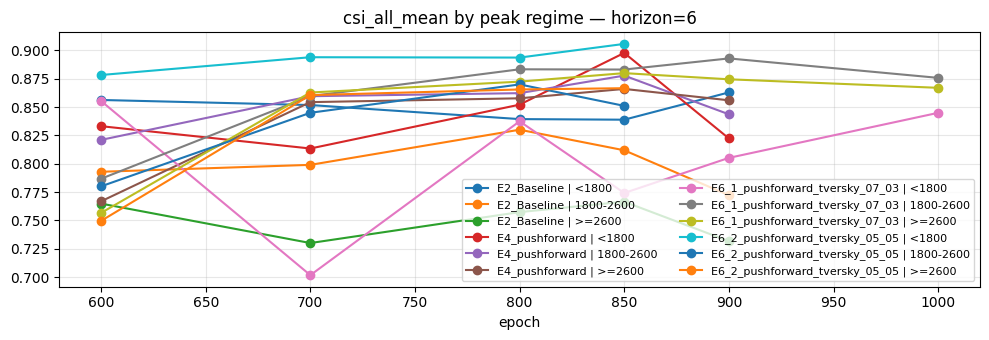

/tmp/ipykernel_3126156/3279351054.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = g.pivot_table(index="epoch", columns="regime", values=metric)
/tmp/ipykernel_3126156/3279351054.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = g.pivot_table(index="epoch", columns="regime", values=metric)
/tmp/ipykernel_3126156/3279351054.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = g.pivot_table(index="epoch", columns="regime", values=metric)
/tmp/ipykernel_3126156/3279351054.py:18: Futur

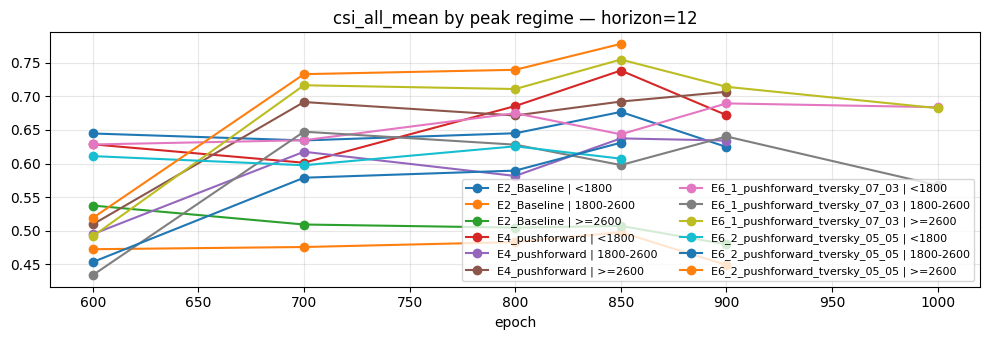

/tmp/ipykernel_3126156/3279351054.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = g.pivot_table(index="epoch", columns="regime", values=metric)
/tmp/ipykernel_3126156/3279351054.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = g.pivot_table(index="epoch", columns="regime", values=metric)
/tmp/ipykernel_3126156/3279351054.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = g.pivot_table(index="epoch", columns="regime", values=metric)
/tmp/ipykernel_3126156/3279351054.py:18: Futur

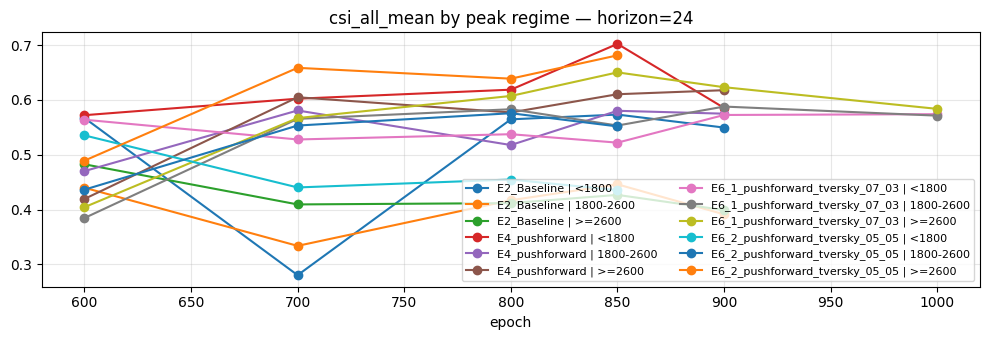

In [8]:
# =====================
# Plots rapides
# =====================

def plot_csi_by_regime(agg_df, horizon_steps, metric="csi_all_mean"):
    sub = agg_df[agg_df["horizon_steps"].eq(horizon_steps)].copy()
    if sub.empty:
        print("No data")
        return

    exps = sorted(sub["exp"].unique())
    regimes = [r for r in PEAK_LABELS if r in sub["regime"].astype(str).unique()]

    fig, ax = plt.subplots(figsize=(10, 3.5))
    for exp in exps:
        g = sub[sub["exp"].eq(exp)].sort_values(["epoch", "regime"])
        # pivot: index=epoch, columns=regime
        pv = g.pivot_table(index="epoch", columns="regime", values=metric)
        for reg in regimes:
            if reg not in pv.columns:
                continue
            ax.plot(pv.index, pv[reg], marker="o", label=f"{exp} | {reg}")

    ax.set_title(f"{metric} by peak regime — horizon={horizon_steps}")
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout();
    plt.show()

for h in HORIZONS_STEPS:
    plot_csi_by_regime(agg, horizon_steps=h, metric="csi_all_mean")


In [9]:
df

,exp,epoch,horizon_steps,event,group,peak,mse_h,mse_u,mse_v,mse_mean,csi_all,csi_int,bias_mean,wet_frac_pred,wet_frac_gt,wet_frac_delta,false_pos_rate,false_neg_rate,regime
0,E2_Baseline,600,6,Group_1_peak_2600_Group_1_peak_2600_0_0-80_int...,1,2600,0.091890,0.020557,0.010411,0.040953,0.753146,0.750733,-0.107556,0.242657,0.311112,-0.068456,0.005194,0.073650,>=2600
1,E2_Baseline,600,12,Group_1_peak_2600_Group_1_peak_2600_0_0-80_int...,1,2600,0.527861,0.101454,0.037723,0.222346,0.509474,0.506202,-0.323124,0.240492,0.457795,-0.217303,0.005813,0.223115,>=2600
2,E2_Baseline,600,24,Group_1_peak_2600_Group_1_peak_2600_0_0-80_int...,1,2600,0.821153,0.139957,0.043695,0.334935,0.408289,0.404901,-0.444907,0.234556,0.524148,-0.289592,0.015893,0.305485,>=2600
3,E2_Baseline,600,6,Group_2_peak_1000_Group_2_peak_1000_0_0-80_int...,2,1000,0.042136,0.015309,0.003916,0.020454,0.832162,0.828822,-0.003065,0.148785,0.135304,0.013481,0.020036,0.006555,<1800
4,E2_Baseline,600,12,Group_2_peak_1000_Group_2_peak_1000_0_0-80_int...,2,1000,0.177612,0.048426,0.008337,0.078125,0.734253,0.730022,-0.101484,0.166409,0.169625,-0.003216,0.024612,0.027828,<1800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,E6_2_pushforward_tversky_05_05,850,12,Group_1_peak_2400_Group_1_peak_2400_0_0-80_int...,1,2400,0.207123,0.034308,0.026610,0.089347,0.689149,0.687116,-0.194401,0.363738,0.433863,-0.070126,0.038897,0.109022,1800-2600
476,E6_2_pushforward_tversky_05_05,850,24,Group_1_peak_2400_Group_1_peak_2400_0_0-80_int...,1,2400,0.542742,0.147786,0.059013,0.249847,0.631817,0.629996,-0.024576,0.513017,0.505844,0.007173,0.119226,0.112052,1800-2600
477,E6_2_pushforward_tversky_05_05,850,6,Group_3_peak_3400_Group_3_peak_3400_0_0-80_int...,3,3400,0.031972,0.008031,0.003431,0.014478,0.882373,0.881384,-0.098513,0.340362,0.352112,-0.011749,0.015954,0.027704,>=2600
478,E6_2_pushforward_tversky_05_05,850,12,Group_3_peak_3400_Group_3_peak_3400_0_0-80_int...,3,3400,0.154571,0.035247,0.018002,0.069273,0.815715,0.814599,-0.219801,0.439367,0.506029,-0.066663,0.014965,0.081628,>=2600


## On regarde si les BC sont bien pris en compte en comparant avec une non augmentation des BCs (on garde celles à t0)

In [6]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import torch

# -----------------------
# Paramètres
# -----------------------
TEST_EXP = list(EXPERIMENTS.keys())[-1]
TEST_EPOCH = 1000
TEST_EVENT = DYNAMIC_DIR[1]
SPLIT = "test"

THR = 0.01  # seuil wet/dry pour CSI et ROI "initial wet"

SEQ_LEN = max(HORIZONS_STEPS) + 1
OVERLAP_TEST = SEQ_LEN - 1
MAX_SEQ = None

ckpt_dir = EXPERIMENTS[TEST_EXP]["ckpt_dir"]
ds = build_dataset_for_event(TEST_EVENT, ckpt_dir, sequence_length=SEQ_LEN, overlap=OVERLAP_TEST, split=SPLIT)

model = build_model()
model = load_model_checkpoint(model, ckpt_dir, epoch=TEST_EPOCH)

# -----------------------
# Normalisation
# -----------------------
stats = ds.node_stats
dyn_start = ds.base_graph.ndata["static"].shape[1]

mx = torch.tensor([stats["h"].item(), stats["u"].item(), stats["v"].item()], device=device)
sx = torch.tensor([stats["h_std"].item(), stats["u_std"].item(), stats["v_std"].item()], device=device)
dy_mean = torch.tensor([stats["delta_h"].item(), stats["delta_u"].item(), stats["delta_v"].item()], device=device)
dy_std = torch.tensor([stats["delta_h_std"].item(), stats["delta_u_std"].item(), stats["delta_v_std"].item()], device=device)

# -----------------------
# Métriques
# -----------------------
def csi_masked(h_pred, h_gt, mask, thr):
    if mask.sum().item() == 0:
        return float("nan")
    hp = h_pred[mask] >= thr
    hg = h_gt[mask] >= thr
    tp = (hp & hg).sum().item()
    fp = (hp & (~hg)).sum().item()
    fn = ((~hp) & hg).sum().item()
    denom = tp + fp + fn
    return tp / denom if denom > 0 else float("nan")

def wet_frac(h, mask, thr):
    if mask.sum().item() == 0:
        return float("nan")
    return (h[mask] >= thr).float().mean().item()

# -----------------------
# Rollout
# -----------------------
def rollout_to_horizons(graphs, q_mask, h_mask, bc_mode, fixed_q=None, fixed_h=None):
    g = graphs[0].to(device)
    static_part = g.ndata["x"][:, :dyn_start]
    xn_t = g.ndata["x"][:, dyn_start:dyn_start + 3]

    captured = {}
    max_h = max(HORIZONS_STEPS)

    for t in range(max_h):
        with torch.no_grad():
            y_pred_n = model(g.ndata["x"], g.edata["x"], g)

        x_t  = _denorm(xn_t, mx, sx)
        dy   = _denorm(y_pred_n, dy_mean, dy_std)
        x_t1 = x_t + dy

        x_gt_n = graphs[t + 1].ndata["x"][:, dyn_start:dyn_start + 3].to(device)
        x_gt   = _denorm(x_gt_n, mx, sx)

        if bc_mode == "gt":
            x_t1[q_mask] = x_gt[q_mask]
            x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]
        elif bc_mode == "fixed":
            x_t1[q_mask] = fixed_q
            x_t1[h_mask, 0:1] = fixed_h
        else:
            raise ValueError(bc_mode)

        step = t + 1
        if step in HORIZONS_STEPS:
            captured[step] = (x_t1.detach().clone(), x_gt.detach().clone())

        xn_t = _renorm(x_t1, mx, sx)
        g = g.clone()
        g.ndata["x"] = torch.cat([static_part, xn_t], dim=1)

    return captured

# -----------------------
# Boucle principale
# -----------------------
rows = []
nseq = len(ds) if MAX_SEQ is None else min(MAX_SEQ, len(ds))

for seq_idx in range(nseq):
    graphs = ds[seq_idx]
    if len(graphs) <= max(HORIZONS_STEPS):
        continue

    g0 = graphs[0].to(device)

    # Masques BC à partir du one-hot
    static_part = g0.ndata["x"][:, :dyn_start]
    onehot = static_part[:, :4]
    q_mask = (onehot == torch.tensor([0, 0, 1, 0], device=device)).all(dim=1)
    h_mask = (onehot == torch.tensor([0, 1, 0, 0], device=device)).all(dim=1)

    # ROI = zone initialement mouillée (t0)
    x0_n = g0.ndata["x"][:, dyn_start:dyn_start + 3]
    x0 = _denorm(x0_n, mx, sx)
    roi = x0[:, 0] >= THR

    # (Optionnel mais souvent souhaitable) exclure les BC de la ROI
    roi = roi & ~(q_mask | h_mask)

    # BC fixées à t0 (unités physiques)
    fixed_q = x0[q_mask].clone()
    fixed_h = x0[h_mask, 0:1].clone()

    cap_gt = rollout_to_horizons(graphs, q_mask, h_mask, bc_mode="gt")
    cap_fx = rollout_to_horizons(graphs, q_mask, h_mask, bc_mode="fixed", fixed_q=fixed_q, fixed_h=fixed_h)

    for h in HORIZONS_STEPS:
        if h not in cap_gt or h not in cap_fx:
            continue

        pred_gt, gt = cap_gt[h]
        pred_fx, _  = cap_fx[h]

        # Effet "BC fixées" vs "BC GT"
        delta_h_roi = (pred_fx[:, 0] - pred_gt[:, 0]).abs()[roi].mean().item() if roi.any() else float("nan")

        # Skill vs GT
        csi_gt = csi_masked(pred_gt[:, 0], gt[:, 0], roi, THR)
        csi_fx = csi_masked(pred_fx[:, 0], gt[:, 0], roi, THR)

        rows.append({
            "seq_idx": seq_idx,
            "horizon": h,
            "roi_count": int(roi.sum().item()),
            "delta_h_roi_mae": delta_h_roi,
            "csi_gtBC_roi": csi_gt,
            "csi_fixedBC_roi": csi_fx,
            "delta_csi_roi": (csi_fx - csi_gt) if (not math.isnan(csi_fx) and not math.isnan(csi_gt)) else float("nan"),
            "wet_gt_roi": wet_frac(gt[:, 0], roi, THR),
            "wet_pred_gtBC_roi": wet_frac(pred_gt[:, 0], roi, THR),
            "wet_pred_fixedBC_roi": wet_frac(pred_fx[:, 0], roi, THR),
        })

df = pd.DataFrame(rows)
display(df.head(10))

summary = df.groupby("horizon").agg(
    n=("seq_idx", "count"),
    roi_count_mean=("roi_count", "mean"),
    delta_h_roi_mae_mean=("delta_h_roi_mae", "mean"),
    delta_h_roi_mae_std=("delta_h_roi_mae", "std"),
    csi_gtBC_roi_mean=("csi_gtBC_roi", "mean"),
    csi_fixedBC_roi_mean=("csi_fixedBC_roi", "mean"),
    delta_csi_roi_mean=("delta_csi_roi", "mean"),
).reset_index()

display(summary)

[09:36:40 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/MeshGraphNet.0.1000.mdlus to device cuda


Loading normalization statistics...


[09:36:40 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience6_2/Seed0/checkpoint.0.1000.pt to device cuda


,seq_idx,horizon,roi_count,delta_h_roi_mae,csi_gtBC_roi,csi_fixedBC_roi,delta_csi_roi,wet_gt_roi,wet_pred_gtBC_roi,wet_pred_fixedBC_roi
0,0,6,2044,0.001490,0.985323,0.985323,0.000000,1.000000,0.985323,0.985323
1,0,12,2044,0.041540,0.985323,0.985323,0.000000,1.000000,0.985323,0.985323
2,0,24,2044,0.294917,0.986301,0.986791,0.000489,1.000000,0.986301,0.986791
3,1,6,2087,0.001636,0.983709,0.983709,0.000000,1.000000,0.983709,0.983709
4,1,12,2087,0.030713,0.984188,0.984667,0.000479,1.000000,0.984188,0.984667
5,1,24,2087,0.232871,0.987063,0.985625,-0.001437,1.000000,0.987063,0.985625
6,2,6,2117,0.025220,0.979206,0.978733,-0.000473,0.999528,0.978743,0.978271
7,2,12,2117,0.120523,0.982050,0.982050,0.000000,1.000000,0.982050,0.982050
8,2,24,2117,0.216349,0.983459,0.983932,0.000473,0.998583,0.983940,0.984412
9,3,6,2153,0.016123,0.980483,0.980483,0.000000,0.999536,0.980028,0.980028


,horizon,n,roi_count_mean,delta_h_roi_mae_mean,delta_h_roi_mae_std,csi_gtBC_roi_mean,csi_fixedBC_roi_mean,delta_csi_roi_mean
0,6,7,2159.571429,0.011055,0.008666,0.981018,0.980951,-0.000068
1,12,7,2159.571429,0.054284,0.035410,0.982522,0.982655,0.000132
2,24,7,2159.571429,0.202190,0.051556,0.972671,0.972544,-0.000127
